In [1]:
%matplotlib inline
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

C:\Users\HP\stats-prob\pymc3-env\lib\site-packages\arviz\__init__.py:50: FutureWarning: 
ArviZ is undergoing a major refactor to improve flexibility and extensibility while maintaining a user-friendly interface.
Some upcoming changes may be backward incompatible.
For details and migration guidance, visit: https://python.arviz.org/en/latest/user_guide/migration_guide.html
  warn(


In [4]:
size = 200
true_intercept = 1
true_slope = 2

x = np.linspace(0, 1, size)
# y = a + b*x
true_regression_line = true_intercept + true_slope * x
# add noise
y = true_regression_line + np.random.normal(scale=.5, size=size)

data = dict(x=x, y=y)

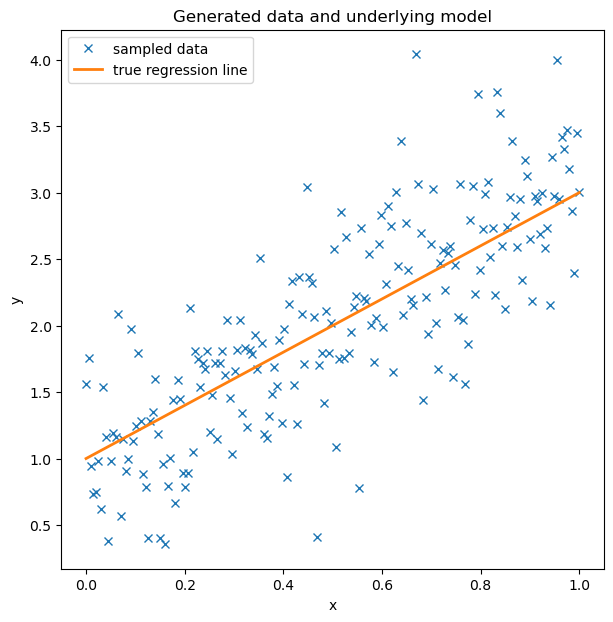

In [5]:
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, xlabel='x', ylabel='y', title='Generated data and underlying model')
ax.plot(x, y, 'x', label='sampled data')
ax.plot(x, true_regression_line, label='true regression line', lw=2.)
plt.legend(loc=0)

In [8]:
with pm.Model() as model: # model specifications in PyMC3 are wrapped in a with-statement
    # Define priors
    sigma = pm.HalfCauchy('sigma', beta=10, initval=1.0)
    intercept = pm.Normal('Intercept', 0, sigma=20)
    x_coeff = pm.Normal('x', 0, sigma=20)

    # Define likelihood
    likelihood = pm.Normal('y', mu=intercept + x_coeff * x, sigma=sigma, observed=y)

    # Inference!
    trace = pm.sample(1000, cores=2, random_seed=42, return_inferencedata=True) # draw 1000 posterior samples using NUTS sampling

C:\Users\HP\stats-prob\pymc3-env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [sigma, Intercept, x]


C:\Users\HP\stats-prob\pymc3-env\lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 1_000 draw iterations (2_000 + 2_000 draws total) took 29 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


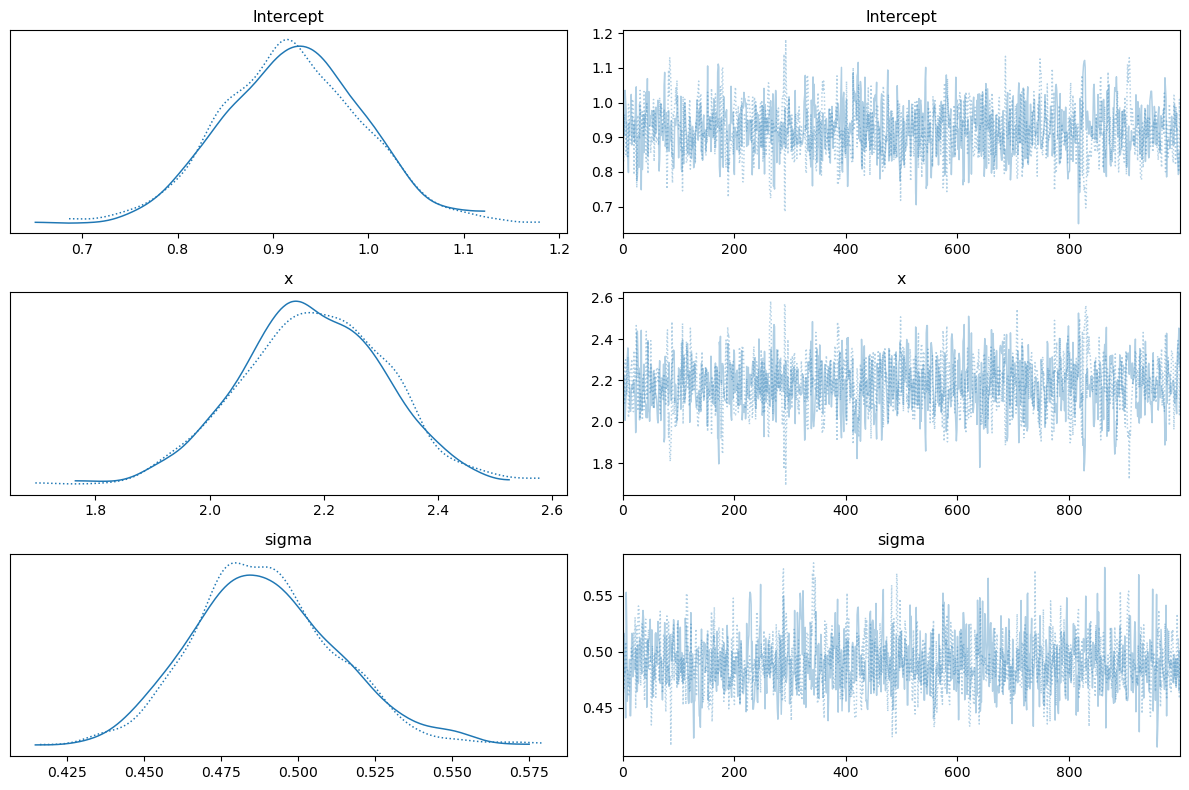

In [10]:
az.plot_trace(trace, figsize=(12, 8))
plt.tight_layout()
plt.show()

In [11]:
print(az.summary(trace))

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
Intercept  0.921  0.073   0.790    1.061      0.002    0.002    1086.0   
x          2.180  0.127   1.945    2.423      0.004    0.004    1087.0   
sigma      0.490  0.024   0.446    0.536      0.001    0.001    1344.0   

           ess_tail  r_hat  
Intercept     997.0    1.0  
x             935.0    1.0  
sigma        1173.0    1.0  


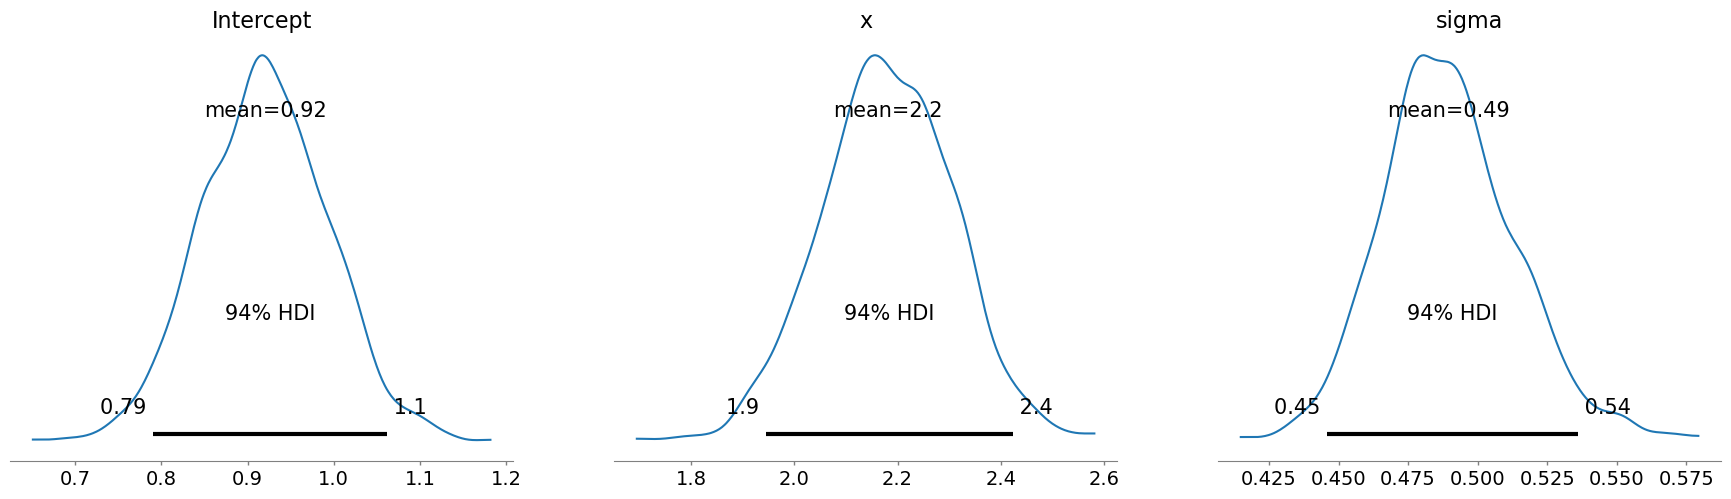

In [12]:
az.plot_posterior(trace)
plt.show()